# Australia Wild Fires analysis

## Goal: To predict wildfire intensities across Australia for future preparation

In [1]:
# Import section

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Data Preparation

Section for preparing and cleaning data

In [2]:
# Load Data
train = pd.read_csv('./wildfire_cls_train_full.csv')
test = pd.read_csv('./wildfire_cls_test_features.csv')

### Perform a Table check

Check the table for any inconsistencies or missing values

In [3]:
train.head()

,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,fire_type,satellite,instrument,brightness_k,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,fire_intensity
0,-22.1967,-61.5275,2024-08-12,1838,2024,NaN,Winter,D,South_America,Peru,Deforestation,Suomi-NPP,VIIRS,360.26,nominal,40.6,39.0,0.11,17.1,Extreme
1,64.2205,-53.4116,2024-07-11,424,2024,7.0,Summer,N,North_America,Canada,Forest,Suomi-NPP,VIIRS,326.20,high,38.9,NaN,0.06,13.2,Low
2,38.6810,9.5739,2024-06-18,546,2024,6.0,Summer,N,Mediterranean,Spain,Wildfire,AQUA,MODIS,343.36,high,36.9,30.1,0.19,35.2,High
3,68.1959,-90.3475,2024-08-26,2240,2024,8.0,Summer,N,North_America,USA,Forest,TERRA,MODIS,389.16,nominal,43.8,17.7,0.98,32.8,Extreme
4,0.6527,118.6227,2025-08-09,2301,2025,8.0,Summer,N,Southeast_Asia,Malaysia,Peatland,TERRA,MODIS,335.68,high,34.8,1.0,0.18,83.2,Moderate


In [4]:
# Checking for NaN values
pd.isna(train).sum()

latitude            0
longitude           0
acq_date            0
acq_time            0
year                0
month             416
season              0
daynight            0
region              0
country             0
fire_type           0
satellite           0
instrument          0
brightness_k      327
confidence          0
temp_max_c          0
wind_max_kmh      207
precip_mm           0
humidity_pct        0
fire_intensity      0
dtype: int64

##### Looking at the table, the dataset is messy and contains many NaN values and can be fixed by using various techniques.

### Missing Month Values

Month values are missing which can be simply solved using the acq_date column as reference

As a bonus for a cleaner database, the acq_time is messy so we simplify it by the hour instead

In [5]:
# Convert acq_date to datetime for month to read
train['acq_date'] = pd.to_datetime(train['acq_date'])
train['month'] = train['acq_date'].dt.month

# Change the acq_time to simply hour for less messy data
train['hour'] = train['acq_time'] // 100
train = train.drop(columns=['acq_time'])

# Rearrange the columns
cols = list(train.columns)

cols.remove('hour')
cols.insert(cols.index('month') + 1, 'hour')

train = train[cols]

# We can drop acq date since we already used it to fill in year month 
# Day is not needed as it has no meaningful pattern and is mostly noise

train = train.drop(columns=['acq_date'])

### Using Median Imputation for missing values

Two columns can use the technique Median Imputation to fill in missing values
- brightness_k
- wind_max_kmh

In [6]:
# Median Imputation for both columns
train['wind_max_kmh'] = train['wind_max_kmh'].fillna(train['wind_max_kmh'].median())
train['brightness_k'] = train['brightness_k'].fillna(train['brightness_k'].median())

In [7]:
pd.isna(train).sum()

latitude          0
longitude         0
year              0
month             0
hour              0
season            0
daynight          0
region            0
country           0
fire_type         0
satellite         0
instrument        0
brightness_k      0
confidence        0
temp_max_c        0
wind_max_kmh      0
precip_mm         0
humidity_pct      0
fire_intensity    0
dtype: int64

Successfully filled in all NaN values with their respective data

### Redundant Data

The data base contains redundant data that can be omitted, specifically satellite and instrument which all matches. This makes the data seem repetitive and we can fix that by omitting a column of choice.

Columns to check:
- satellite
- instrument

The code below shows that each satellite has only one unique instrument

In [8]:
# Check unique instrument for each satellite
train.groupby('satellite')['instrument'].nunique()

satellite
AQUA         1
NOAA-20      1
Suomi-NPP    1
TERRA        1
Name: instrument, dtype: int64

In [9]:
# Column that is chosen to be dropped is instrument
train = train.drop(columns=['instrument'])

### Fire intensity column

The target variable fire_intensity was originally represented as categorical labels (Low, Moderate, High, Extreme). These labels were encoded into numerical values (0–3) to make them suitable for machine learning models.

In [10]:
train['fire_intensity'] = train['fire_intensity'].map({
    'Low': 0,
    'Moderate': 1,
    'High': 2,
    'Extreme': 3
})

In [11]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   latitude        4340 non-null   float64
 1   longitude       4340 non-null   float64
 2   year            4340 non-null   int64  
 3   month           4340 non-null   int32  
 4   hour            4340 non-null   int64  
 5   season          4340 non-null   str    
 6   daynight        4340 non-null   str    
 7   region          4340 non-null   str    
 8   country         4340 non-null   str    
 9   fire_type       4340 non-null   str    
 10  satellite       4340 non-null   str    
 11  brightness_k    4340 non-null   float64
 12  confidence      4340 non-null   str    
 13  temp_max_c      4340 non-null   float64
 14  wind_max_kmh    4340 non-null   float64
 15  precip_mm       4340 non-null   float64
 16  humidity_pct    4340 non-null   float64
 17  fire_intensity  4340 non-null   int64  
dtyp

In [12]:
train.head()

,latitude,longitude,year,month,hour,season,daynight,region,country,fire_type,satellite,brightness_k,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,fire_intensity
0,-22.1967,-61.5275,2024,8,18,Winter,D,South_America,Peru,Deforestation,Suomi-NPP,360.26,nominal,40.6,39.0,0.11,17.1,3
1,64.2205,-53.4116,2024,7,4,Summer,N,North_America,Canada,Forest,Suomi-NPP,326.20,high,38.9,12.4,0.06,13.2,0
2,38.6810,9.5739,2024,6,5,Summer,N,Mediterranean,Spain,Wildfire,AQUA,343.36,high,36.9,30.1,0.19,35.2,2
3,68.1959,-90.3475,2024,8,22,Summer,N,North_America,USA,Forest,TERRA,389.16,nominal,43.8,17.7,0.98,32.8,3
4,0.6527,118.6227,2025,8,23,Summer,N,Southeast_Asia,Malaysia,Peatland,TERRA,335.68,high,34.8,1.0,0.18,83.2,1


<p align="center">
* The same data preparation steps will be applied to the test dataset using statistics derived from the training data to ensure consistency and avoid data leakage.
</p>

# Exploratory Data Analysis (EDA)

Here we will explore different columns and how they relate to fire intensity

In [13]:
train.describe()

,latitude,longitude,year,month,hour,brightness_k,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,fire_intensity
count,4340.000000,4340.000000,4340.000000,4340.000000,4340.000000,4340.000000,4340.000000,4340.000000,4340.000000,4340.000000,4340.000000
mean,9.821703,29.430626,2024.501843,7.227419,11.476959,336.591265,35.082627,17.264401,2.597111,37.924378,1.323502
std,24.321271,78.842700,0.500054,2.806116,6.834438,17.829524,5.821218,16.675842,3.062512,18.731153,0.846315
min,-42.988300,-167.990600,2024.000000,1.000000,0.000000,290.000000,17.700000,0.000000,0.000000,5.000000,0.000000
25%,-8.611625,-40.980600,2024.000000,5.000000,6.000000,325.952500,31.000000,5.400000,0.600000,24.200000,1.000000
50%,10.268500,34.833700,2025.000000,8.000000,12.000000,335.530000,35.100000,12.400000,1.540000,36.200000,1.000000
75%,29.011025,95.166775,2025.000000,9.000000,17.000000,345.852500,39.125000,23.200000,3.370000,50.500000,2.000000
max,69.930900,153.754900,2025.000000,12.000000,23.000000,503.710000,54.100000,130.700000,23.690000,95.000000,3.000000


Looking at the count or frequency of each row for fire intensity we can see Moderate (1) being the most likely to show up followed by High (2) and then Low (0). Finally the least to show up is Extreme (3)

In [14]:
train['fire_intensity'].value_counts()

fire_intensity
1    1921
2    1340
0     698
3     381
Name: count, dtype: int64

In [15]:
train['fire_intensity'].value_counts(normalize=True)

fire_intensity
1    0.442627
2    0.308756
0    0.160829
3    0.087788
Name: proportion, dtype: float64

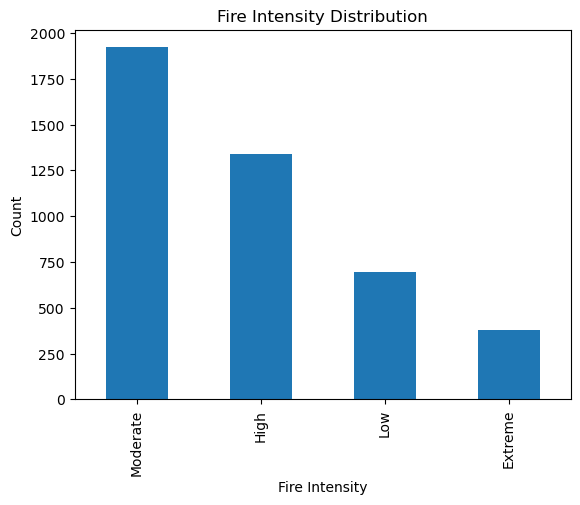

In [16]:
labels = {0: 'Low', 1: 'Moderate', 2: 'High', 3: 'Extreme'}

train['fire_intensity'].map(labels).value_counts().plot(kind='bar')
plt.title("Fire Intensity Distribution")
plt.xlabel("Fire Intensity")
plt.ylabel("Count")
plt.show()

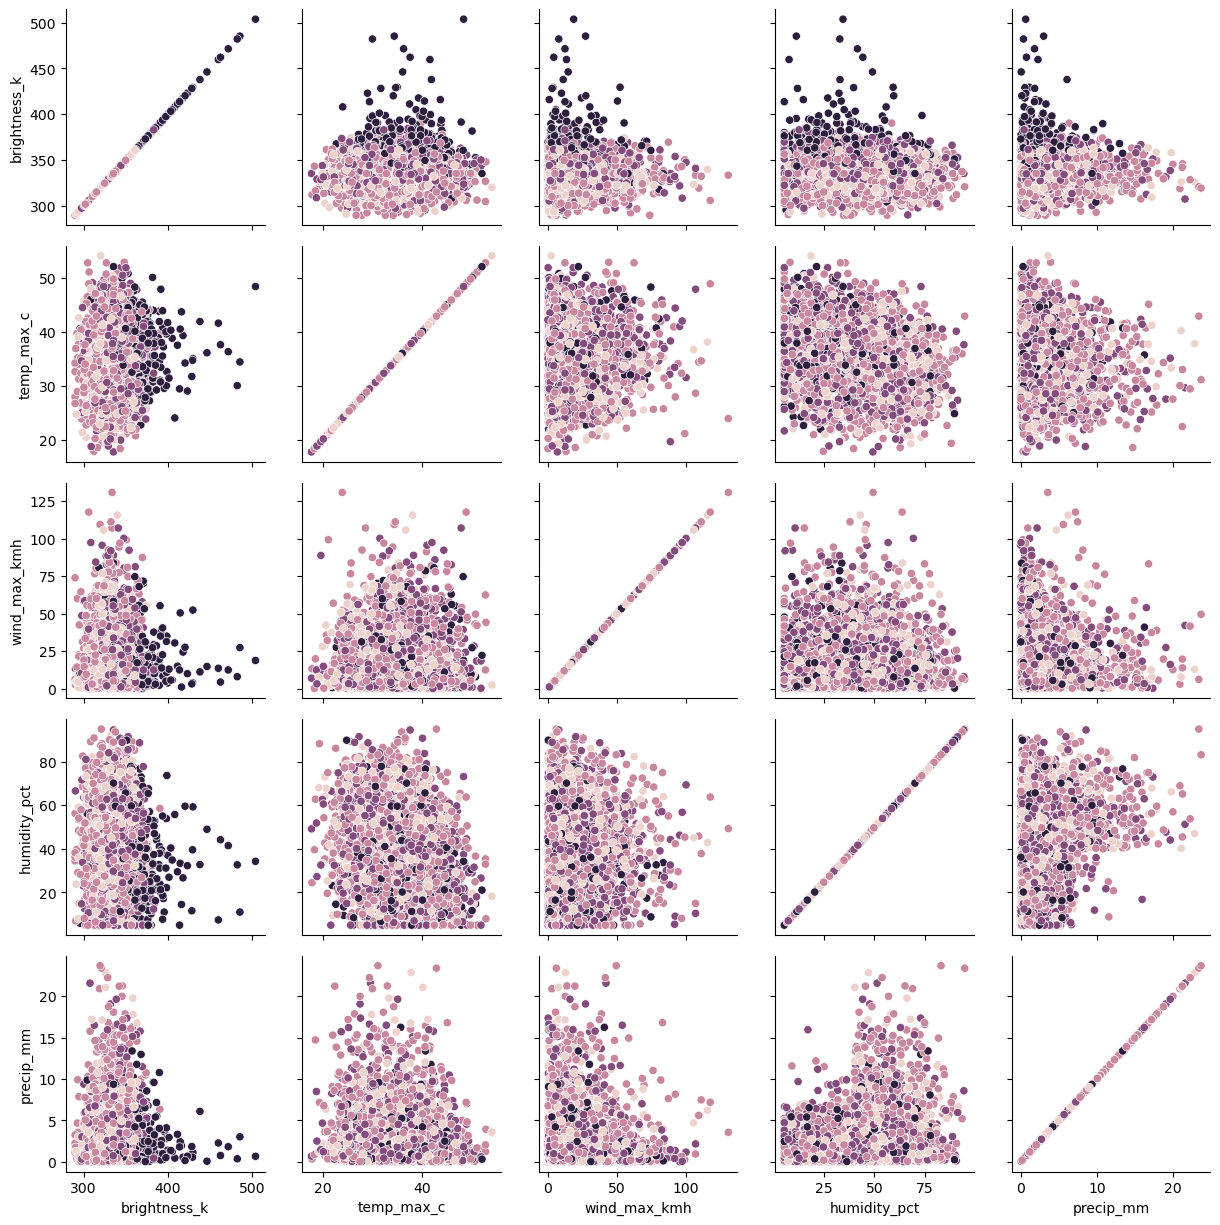

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

selected_features = [
    'brightness_k',
    'temp_max_c',
    'wind_max_kmh',
    'humidity_pct',
    'precip_mm'
]

g = sns.PairGrid(
    train,
    vars=selected_features,
    hue='fire_intensity'
)

g.map(sns.scatterplot)

plt.show()

### Comparison of Different Variables to Fire Intensity

Here is a brief comparison of the variables in how they effect fire intensity

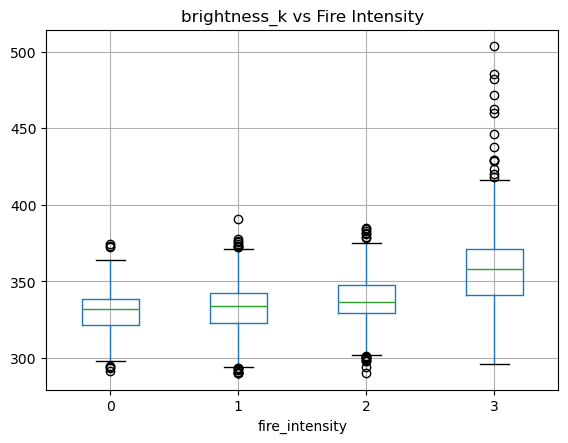

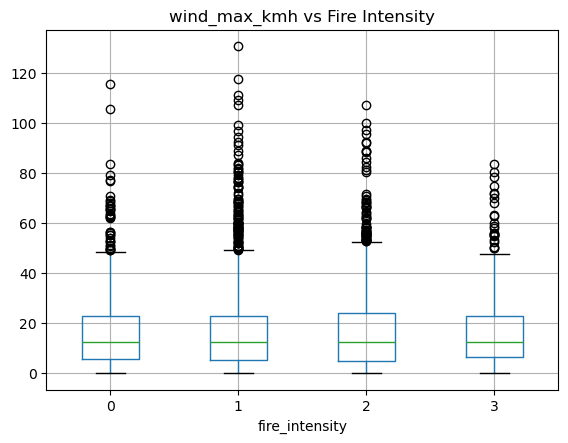

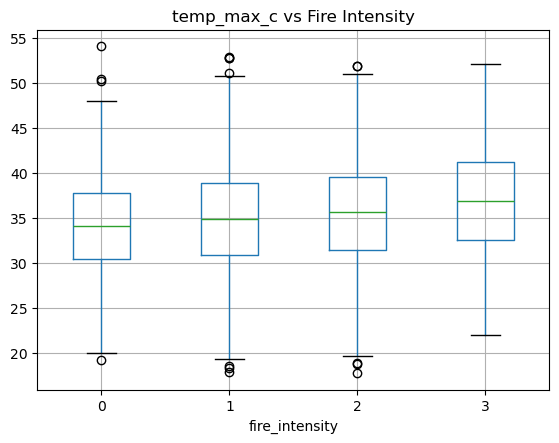

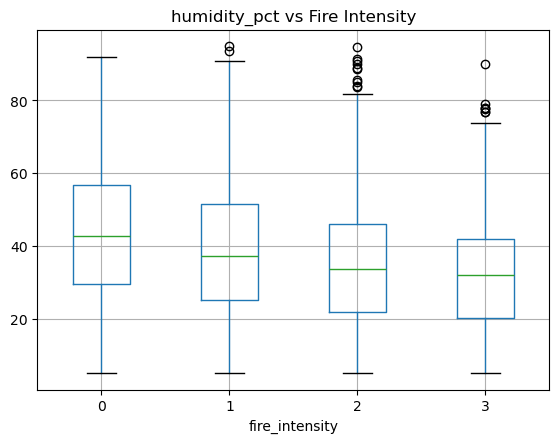

In [18]:
cols = ['brightness_k', 'wind_max_kmh', 'temp_max_c', 'humidity_pct']

for col in cols:
    train.boxplot(column=col, by='fire_intensity')
    plt.title(f"{col} vs Fire Intensity")
    plt.suptitle("")
    plt.show()

### Analysis Results

- Brightness increases with fire intensity, showing a clear positive relationship.

- Wind speed shows no clear relationship with fire intensity.

- Temperature slightly increases with fire intensity, indicating a weak positive trend.

- Humidity decreases as fire intensity increases, suggesting a negative relationship.

### Correlation Heatmap

Heatmap to check how strong the relationship between variables are

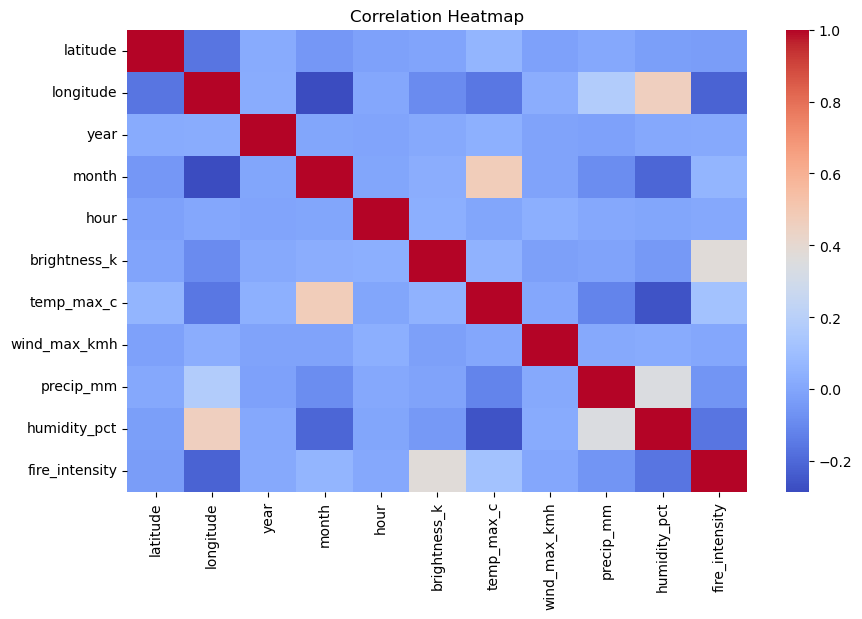

In [19]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(train.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Analysis Results
- Brightness_k shows the strongest positive relationship with fire intensity, indicating it is a key predictor.
  
- Temperature (temp_max_c) has a weak positive correlation with fire intensity.

- Humidity (humidity_pct) shows a negative relationship, suggesting higher humidity is associated with lower fire intensity.

- Precipitation (precip_mm) also shows a slight negative correlation with fire intensity.

- Wind speed (wind_max_kmh) does not show a significant relationship with fire intensity.

# Preprocessing

Moving to preprocessing to make data more readable by machine learning methods

In [20]:
# Separate the data set into x and y where x is everythign else and y is the fire intensity only.

X = train.drop(columns=['fire_intensity'])
y = train['fire_intensity']

### One hot encoding
Moving on to One-hot encoding for machine learning model to read data more efficiently

In [21]:
X = pd.get_dummies(X, drop_first=True)
X = X.astype(float)

In [22]:
# Small table check
X.head()

,latitude,longitude,year,month,hour,brightness_k,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,...,fire_type_Peatland,fire_type_Prescribed,fire_type_Savanna,fire_type_Shrubland,fire_type_Wildfire,satellite_NOAA-20,satellite_Suomi-NPP,satellite_TERRA,confidence_low,confidence_nominal
0,-22.1967,-61.5275,2024.0,8.0,18.0,360.26,40.6,39.0,0.11,17.1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,64.2205,-53.4116,2024.0,7.0,4.0,326.20,38.9,12.4,0.06,13.2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,38.6810,9.5739,2024.0,6.0,5.0,343.36,36.9,30.1,0.19,35.2,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,68.1959,-90.3475,2024.0,8.0,22.0,389.16,43.8,17.7,0.98,32.8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,0.6527,118.6227,2025.0,8.0,23.0,335.68,34.8,1.0,0.18,83.2,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


### Train Validation Split

Splitting the training data to a 80% train and 20% validation split. 

In [23]:
#Split model into train and validation
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
# Raw version for decision tree

X_train_raw = X_train.copy()
X_val_raw = X_val.copy()

# Scaling for svm and nn

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Model Training

Moving on to the model training for Decision Tree, SVM and Neural Networks.

Here is a helper function (`get_scores`) that is used to calculate training and validation Macro F1-score and accuracy for each model.

In [25]:
from sklearn.metrics import f1_score, accuracy_score, classification_report

In [26]:
def get_scores(clf, train_X, train_y, val_X, val_y):
    train_pred = clf.predict(train_X)
    val_pred = clf.predict(val_X)

    train_f1 = f1_score(train_y, train_pred, average='macro')
    val_f1 = f1_score(val_y, val_pred, average='macro')

    train_acc = accuracy_score(train_y, train_pred)
    val_acc = accuracy_score(val_y, val_pred)

    return train_f1, val_f1, train_acc, val_acc

## Decision Tree

The baseline Decision Tree shows severe overfitting, with very high training performance but much lower validation performance.
This indicates the model is too complex and does not generalise well.

In [27]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train_raw, y_train)

train_f1, val_f1, train_acc, val_acc = get_scores(
    tree, X_train_raw, y_train, X_val_raw, y_val
)

print("Baseline Decision Tree")
print("Train F1:", train_f1)
print("Val F1:", val_f1)

Baseline Decision Tree
Train F1: 1.0
Val F1: 0.362303463228994


## SVM 

The SVM model shows similar training and validation performance, indicating less overfitting but overall weaker predictive performance.

In [28]:
from sklearn.svm import SVC

svm = SVC(kernel='linear', C=1.0)

svm.fit(X_train, y_train)

train_f1, val_f1, train_acc, val_acc = get_scores(
    svm, X_train, y_train, X_val, y_val
)

print("Baseline SVM")
print("Train F1:", train_f1)
print("Val F1:", val_f1)

Baseline SVM
Train F1: 0.32993513908574335
Val F1: 0.31109887530232927


## Neural Networks

The baseline Neural Network shows signs of overfitting, with much higher training performance compared to validation performance.

In [29]:
from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(
    hidden_layer_sizes=(64,),
    max_iter=500,
    random_state=42
)

nn.fit(X_train, y_train)

train_f1, val_f1, train_acc, val_acc = get_scores(
    nn, X_train, y_train, X_val, y_val
)

print("Baseline Neural Network")
print("Train F1:", train_f1)
print("Val F1:", val_f1)

Baseline Neural Network
Train F1: 0.9024930347418929
Val F1: 0.34150704797136094


/Users/Vadhthanak/opt/anaconda3/envs/mlclean/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


# Hyperparameter tuning

The hyperparameter tuning will happen here and will help achieve better F1-Scores for each model

## Decision Tree

Different maximum depth values are tested to tune the Decision Tree hyperparameter and improve model performance.

The tested depths include:
- 3 (low complexity)
- 5 (medium complexity)
- 7 (higher complexity)
- 10 and 15 (very high complexity)
- None (unlimited depth)

In [30]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

depths = [3, 5, 7, 10, 15, 20, 25, 30, 35, None]

dt_train_f1 = []
dt_val_f1 = []

for depth in depths:
    dt = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    dt.fit(X_train_raw, y_train)

    train_f1, val_f1, train_acc, val_acc = get_scores(
        dt, X_train_raw, y_train, X_val_raw, y_val
    )

    dt_train_f1.append(train_f1)
    dt_val_f1.append(val_f1)

    print("max_depth:", depth)
    print("Train F1: {:.3f}".format(train_f1))
    print("Val F1: {:.3f}".format(val_f1))
    print()

max_depth: 3
Train F1: 0.374
Val F1: 0.357

max_depth: 5
Train F1: 0.373
Val F1: 0.331

max_depth: 7
Train F1: 0.474
Val F1: 0.352

max_depth: 10
Train F1: 0.606
Val F1: 0.313

max_depth: 15
Train F1: 0.802
Val F1: 0.371

max_depth: 20
Train F1: 0.931
Val F1: 0.342

max_depth: 25
Train F1: 0.988
Val F1: 0.344

max_depth: 30
Train F1: 0.998
Val F1: 0.357

max_depth: 35
Train F1: 1.000
Val F1: 0.362

max_depth: None
Train F1: 1.000
Val F1: 0.362



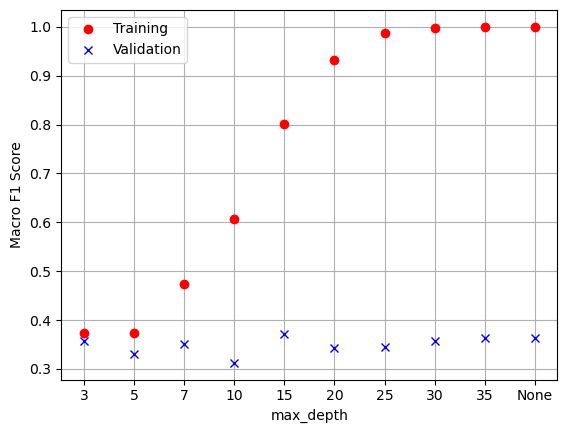

In [31]:
plt.plot([str(d) for d in depths], dt_train_f1, 'ro')
plt.plot([str(d) for d in depths], dt_val_f1, 'bx')
plt.xlabel("max_depth")
plt.ylabel("Macro F1 Score")
plt.legend(["Training", "Validation"])
plt.grid()
plt.show()

In [32]:
best_depth = depths[dt_val_f1.index(max(dt_val_f1))]

best_dt = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

best_dt.fit(X_train_raw, y_train)

train_f1, val_f1, train_acc, val_acc = get_scores(
    best_dt, X_train_raw, y_train, X_val_raw, y_val
)

print("Best Decision Tree")
print("Best max_depth:", best_depth)
print("Train F1: {:.3f}".format(train_f1))
print("Val F1: {:.3f}".format(val_f1))

Best Decision Tree
Best max_depth: 15
Train F1: 0.802
Val F1: 0.371


## SVM

To find the best hyperparameters for the SVM model, different kernels are first tested. After selecting the best-performing kernel, the hyperparameter C is tuned to improve performance.

In [33]:
from sklearn.svm import SVC

kernels = ['linear', 'rbf', 'poly', 'sigmoid']

svm_train_f1 = []
svm_val_f1 = []

for k in kernels:
    svm = SVC(
        kernel=k,
        C=1.0,
        random_state=42
    )

    svm.fit(X_train, y_train)

    train_f1, val_f1, _, _ = get_scores(
        svm, X_train, y_train, X_val, y_val
    )

    svm_train_f1.append(train_f1)
    svm_val_f1.append(val_f1)

    print("Kernel:", k)
    print("Train F1:", train_f1)
    print("Val F1:", val_f1)
    print()

Kernel: linear
Train F1: 0.32993513908574335
Val F1: 0.31109887530232927

Kernel: rbf
Train F1: 0.3906888109451773
Val F1: 0.3006349550297993

Kernel: poly
Train F1: 0.4541164958612498
Val F1: 0.2787022451237708

Kernel: sigmoid
Train F1: 0.29055679470218143
Val F1: 0.32976530244233404



In [34]:
best_kernel = 'sigmoid'

C_values = [0.01, 0.1, 1, 10, 100]

svm_c_train_f1 = []
svm_c_val_f1 = []

for C in C_values:
    svm = SVC(
        kernel=best_kernel,
        C=C,
        random_state=42
    )

    svm.fit(X_train, y_train)

    train_f1, val_f1, _, _ = get_scores(
        svm, X_train, y_train, X_val, y_val
    )

    svm_c_train_f1.append(train_f1)
    svm_c_val_f1.append(val_f1)

    print("C:", C)
    print("Train F1:", train_f1)
    print("Val F1:", val_f1)
    print()

C: 0.01
Train F1: 0.15342383709323218
Val F1: 0.15335463258785942

C: 0.1
Train F1: 0.20187253315095
Val F1: 0.19571236038301906

C: 1
Train F1: 0.29055679470218143
Val F1: 0.32976530244233404

C: 10
Train F1: 0.272542035986458
Val F1: 0.35497236949417604

C: 100
Train F1: 0.28829653597099675
Val F1: 0.3757638857662673



In [35]:
# Gamma tuning
best_C = 100

gamma_values = ['scale', 'auto', 0.001, 0.01, 0.1, 1]

svm_gamma_train_f1 = []
svm_gamma_val_f1 = []

for gamma in gamma_values:
    svm = SVC(
        kernel=best_kernel,
        C=best_C,
        gamma=gamma,
        random_state=42
    )

    svm.fit(X_train, y_train)

    train_f1, val_f1, _, _ = get_scores(
        svm, X_train, y_train, X_val, y_val
    )

    svm_gamma_train_f1.append(train_f1)
    svm_gamma_val_f1.append(val_f1)

    print("Gamma:", gamma)
    print("Train F1:", train_f1)
    print("Val F1:", val_f1)
    print()

Gamma: scale
Train F1: 0.28829653597099675
Val F1: 0.3757638857662673

Gamma: auto
Train F1: 0.28829653597099675
Val F1: 0.3757638857662673

Gamma: 0.001
Train F1: 0.32223370287529585
Val F1: 0.31982799091513753

Gamma: 0.01
Train F1: 0.2897945714313392
Val F1: 0.3898761390065804

Gamma: 0.1
Train F1: 0.279951437307663
Val F1: 0.3113940516573731

Gamma: 1
Train F1: 0.2755976454491268
Val F1: 0.3182773972640677



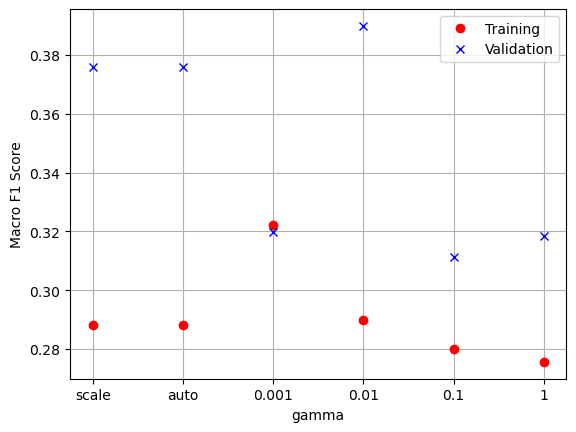

In [36]:
plt.plot(gamma_values, svm_gamma_train_f1, 'ro')
plt.plot(gamma_values, svm_gamma_val_f1, 'bx')
plt.xlabel("gamma")
plt.ylabel("Macro F1 Score")
plt.legend(["Training", "Validation"])
plt.grid()
plt.show()

## Neural Networks

To improve Neural Network performance, different learning rates are tested to determine which value provides the best validation performance while reducing overfitting.

In [37]:
learning_rates = [0.0001, 0.001, 0.01, 0.1, 1]

nn_train_f1 = []
nn_val_f1 = []

for lr in learning_rates:
    nn = MLPClassifier(
        hidden_layer_sizes=(64,),
        learning_rate_init=lr,
        max_iter=500,
        random_state=42
    )

    nn.fit(X_train, y_train)

    train_f1, val_f1, _, _ = get_scores(
        nn, X_train, y_train, X_val, y_val
    )

    nn_train_f1.append(train_f1)
    nn_val_f1.append(val_f1)

    print("Learning rate:", lr)
    print("Train F1:", train_f1)
    print("Val F1:", val_f1)
    print()

/Users/Vadhthanak/opt/anaconda3/envs/mlclean/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Learning rate: 0.0001
Train F1: 0.5610766112438684
Val F1: 0.3918793160076437



/Users/Vadhthanak/opt/anaconda3/envs/mlclean/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Learning rate: 0.001
Train F1: 0.9024930347418929
Val F1: 0.34150704797136094

Learning rate: 0.01
Train F1: 0.9539690426808548
Val F1: 0.358107566870363

Learning rate: 0.1
Train F1: 0.6356666474266929
Val F1: 0.3972845997793488

Learning rate: 1
Train F1: 0.373684893279044
Val F1: 0.3264824542730283



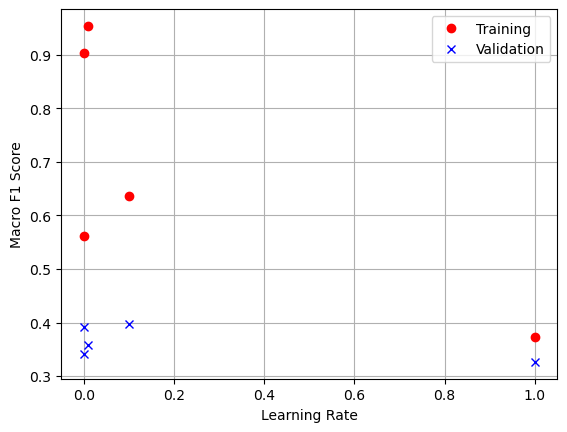

In [38]:
plt.plot(learning_rates, nn_train_f1, 'ro')
plt.plot(learning_rates, nn_val_f1, 'bx')
plt.xlabel("Learning Rate")
plt.ylabel("Macro F1 Score")
plt.legend(["Training", "Validation"])
plt.grid()
plt.show()

# Model Comparison

Here we will compare the performance of all models and choosing the best model to be used

In [39]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "SVM", "Neural Network"],

    "Best Hyperparameter": [
        "max_depth = 15",
        "kernel = sigmoid, C = 100, gamma = 0.01",
        "learning_rate = 0.1"
    ],

    "Train F1": [
        1.000000,          # Decision Tree train F1 for depth 15
        0.28979,          # SVM train F1 for C = 100, Gamma = 0.01
        0.635667           # Neural Network train F1 for lr = 0.1
    ],

    "Validation F1": [
        0.371319,          # Decision Tree validation F1
        0.389876,          # SVM validation F1
        0.397285           # Neural Network validation F1
    ]
})

comparison.sort_values(by="Validation F1", ascending=False)

,Model,Best Hyperparameter,Train F1,Validation F1
2,Neural Network,learning_rate = 0.1,0.635667,0.397285
1,SVM,"kernel = sigmoid, C = 100, gamma = 0.01",0.289790,0.389876
0,Decision Tree,max_depth = 15,1.000000,0.371319


After doing multiple tests, Neural Networks seemed to perform the best consistantly followed by decision tree and finally SVM

# Model Selection

In this section it is finally time to select the best training model for the fire intensity predicitons

The selected model will be Neural Network with a learning rate of "0.01"

## Test data cleaning

Like said before, the test data will be cleaned just like the train data

In [40]:
# Clean test data using the same steps as training data
test_clean = test.copy()

# Convert date and extract month
test_clean['acq_date'] = pd.to_datetime(test_clean['acq_date'])
test_clean['month'] = test_clean['acq_date'].dt.month

# Convert acquisition time into hour
test_clean['hour'] = test_clean['acq_time'] // 100

# Drop unused columns
test_clean = test_clean.drop(columns=['acq_date', 'acq_time', 'instrument'])

# Fill missing values using training medians
test_clean['wind_max_kmh'] = test_clean['wind_max_kmh'].fillna(train['wind_max_kmh'].median())
test_clean['brightness_k'] = test_clean['brightness_k'].fillna(train['brightness_k'].median())

# One-hot encode test data
test_clean = pd.get_dummies(test_clean, drop_first=True)
test_clean = test_clean.astype(float)

# Match test columns to training columns
test_clean = test_clean.reindex(columns=X.columns, fill_value=0)

# Check shape
print("Training columns:", X.shape)
print("Test columns:", test_clean.shape)

Training columns: (4340, 68)
Test columns: (1085, 68)


## Predictions

Predicitons will happen here by using neural network methods

In [41]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Scale full training data and test data
final_scaler = StandardScaler()

X_full_scaled = final_scaler.fit_transform(X)
test_scaled = final_scaler.transform(test_clean)

# Final selected model
final_nn = MLPClassifier(
    hidden_layer_sizes=(64,),
    learning_rate_init=0.1,
    max_iter=500,
    random_state=42
)

# Train on full training dataset
final_nn.fit(X_full_scaled, y)

# Predict test data
test_predictions = final_nn.predict(test_scaled)

# Convert numerical predictions back to labels
label_map = {
    0: "Low",
    1: "Moderate",
    2: "High",
    3: "Extreme"
}

test_predictions = pd.Series(test_predictions).map(label_map)

# Create submission file
submission = pd.DataFrame({
    "fire_intensity": test_predictions
})

# Export CSV
submission.to_csv("s3951117_predictions.csv", index=False)

submission.head()

,fire_intensity
0,High
1,Extreme
2,Moderate
3,High
4,Moderate


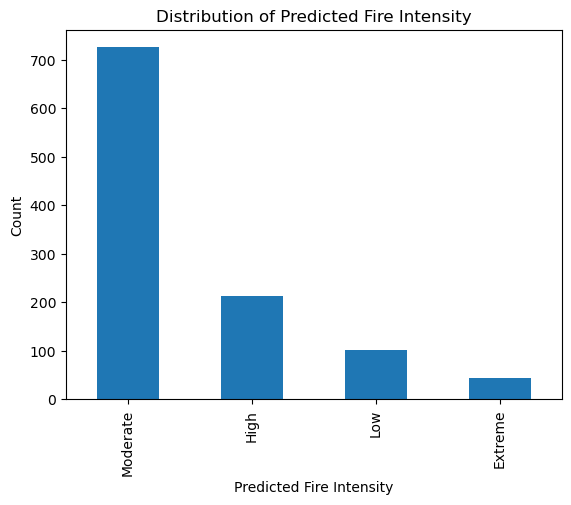

In [42]:
submission['fire_intensity'].value_counts().plot(kind='bar')

plt.xlabel("Predicted Fire Intensity")
plt.ylabel("Count")
plt.title("Distribution of Predicted Fire Intensity")

plt.show()